## **KIỂM TRA MÔI TRƯỜNG: VS CODE, WINDOWS, CPU**


In [1]:
import sys
import os
import platform
import torch

print("Python", sys.version.split()[0])
print("Platform", platform.platform())
print("PyTorch", torch.__version__)
print("CUDA available", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    print("GPU", torch.cuda.get_device_name(0))
else:
    print("Device CPU")

CPU_THREADS = max(1, (os.cpu_count() or 4) - 1)
torch.set_num_threads(CPU_THREADS)

print("CPU threads", torch.get_num_threads())


Python 3.11.9
Platform Windows-10-10.0.26200-SP0
PyTorch 2.13.0+cpu
CUDA available False
Device CPU
CPU threads 11


## **CÀI THƯ VIỆN LOCAL**

Chỉ chạy cell dưới nếu máy thiếu thư viện hoặc import lỗi. Không cài lại `torch` để tránh làm hỏng bản PyTorch CPU hiện tại.

Nếu cell báo đã gỡ `torchvision` do lỗi tương thích, hãy `Restart Kernel` trong VS Code. Chạy lại notebook từ cell **KIỂM TRA MÔI TRƯỜNG**.

Restart Kernel trong VS Code rồi chạy lại notebook

In [ ]:
%pip uninstall -y numpy scipy

%pip install --no-cache-dir --force-reinstall numpy scipy

%pip install --no-cache-dir --upgrade \
    "transformers>=4.44,<5" \
    "sentence-transformers>=3.0" \
    pillow \
    accelerate \
    pandas \
    tqdm \
    matplotlib \
    safetensors

print("Đã cài xong")

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: scipy 1.14.1
Uninstalling scipy-1.14.1:
  Successfully uninstalled scipy-1.14.1
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.


   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 4.2 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/12.6 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.6 MB 3.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.6 MB 3.9 MB/s eta 0:00:03
   ----------- ---------------------------- 3.7/12.6 MB 3.8 MB/s eta 0:00:03
   -------------- ------------------------- 4.5/12.6 MB 3.9 MB/s eta 0:00:03
   ----------------- ---------------------- 5.5/12.6 MB 4.0 MB/s eta 0:00:02
   ------------------- -------------------- 6.3/12.6 MB 4.0 MB/s eta 0:00:02
   ---------------------- ----------------- 7.1/12.6 MB 4.0 MB/s eta 0:00:02
   ------------------------ --------------- 7.9/12.6 MB 4.0 MB/s eta 0:00:02
   -------------------------- ------------- 8.4/12.6 MB 3.9 MB/s eta 0:00:02
   ----------------------------- ---------- 9.2/12.6 MB 3.9 MB/s eta 0:00:01
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.4.6 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Nguyen Ho Vinh  Hien\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


INFO: pip is looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.
Đã cài lại NumPy + SciPy + Sentence-Transformers



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Nguyen Ho Vinh  Hien\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## **CẤU TRÚC THƯ MỤC LOCAL**

Dataset:
```text
C:\Users\Nguyen Ho Vinh  Hien\Downloads\FashionIQ\fashionIQ_dataset
├── captions\
├── images\
└── image_splits\
```

Notebook và output:
```text
C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37
└── embeddings\
    ├── sentence_bert\
    ├── fashion_clip\
    └── image_chunks\
```


## **CONFIG**

Đây là cell cấu hình chính, chạy lại cell này mỗi khi Restart Kernel.

Vì máy hiện không có NVIDIA GPU nên `FCLIP_IMAGE_BATCH = 8` để ổn định RAM/CPU và `IMAGE_CHUNK_SIZE = 500` để checkpoint thường xuyên, tránh mất nhiều tiến độ khi dừng.


In [3]:
from pathlib import Path
import os
import torch

WORK_ROOT = Path(r"C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37")
DATA_ROOT = Path(r"C:\Users\Nguyen Ho Vinh  Hien\Downloads\FashionIQ\fashionIQ_dataset")

OUTPUT_ROOT = WORK_ROOT / "embeddings"

CAPTIONS_DIR = DATA_ROOT / "captions"
IMAGES_DIR = DATA_ROOT / "images"
SPLITS_DIR = DATA_ROOT / "image_splits"

# MODEL
SBERT_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
FCLIP_MODEL_NAME = "patrickjohncyh/fashion-clip"

# BATCH / CHECKPOINT
SBERT_BATCH = 64
FCLIP_TEXT_BATCH = 64

FCLIP_IMAGE_BATCH = 8

IMAGE_CHUNK_SIZE = 500

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cpu":
    CPU_THREADS = max(1, (os.cpu_count() or 4) - 1)
    torch.set_num_threads(CPU_THREADS)

# OUTPUT FOLDERS
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "sentence_bert").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "fashion_clip").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "image_chunks").mkdir(parents=True, exist_ok=True)

print("WORK_ROOT ", WORK_ROOT)
print("DATA_ROOT ", DATA_ROOT)
print("OUTPUT_ROOT ", OUTPUT_ROOT)
print("Device ", device)
print("FCLIP_IMAGE_BATCH ", FCLIP_IMAGE_BATCH)
print("IMAGE_CHUNK_SIZE ", IMAGE_CHUNK_SIZE)

assert WORK_ROOT.exists(), f"Không tìm thấy WORK_ROOT: {WORK_ROOT}"
assert DATA_ROOT.exists(), f"Không tìm thấy DATA_ROOT: {DATA_ROOT}"


WORK_ROOT  C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37
DATA_ROOT  C:\Users\Nguyen Ho Vinh  Hien\Downloads\FashionIQ\fashionIQ_dataset
OUTPUT_ROOT  C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings
Device  cpu
FCLIP_IMAGE_BATCH  8
IMAGE_CHUNK_SIZE  500


## **KIỂM TRA CẤU TRÚC FashionIQ**


In [5]:
assert DATA_ROOT.exists(), f"Không tìm thấy DATA_ROOT: {DATA_ROOT}"
assert CAPTIONS_DIR.exists(), f"Không tìm thấy captions/: {CAPTIONS_DIR}"
assert IMAGES_DIR.exists(), f"Không tìm thấy images/: {IMAGES_DIR}"
assert SPLITS_DIR.exists(), f"Không tìm thấy image_splits/: {SPLITS_DIR}"

print("DATA_ROOT OK")
print("CAPTIONS_DIR OK")
print("IMAGES_DIR OK")
print("SPLITS_DIR OK")


DATA_ROOT OK
CAPTIONS_DIR OK
IMAGES_DIR OK
SPLITS_DIR OK


In [6]:
caption_files = sorted(CAPTIONS_DIR.glob("*.json"))

print("Số caption JSON ", len(caption_files))
print("5 caption files đầu ")

for p in caption_files[:5]:
    print(" -", p.name)

Số caption JSON  12
5 caption files đầu 
 - cap.dress.test.json
 - cap.dress.train.json
 - cap.dress.val.json
 - cap.shirt.test.json
 - cap.shirt.train.json


In [7]:
split_files = sorted(SPLITS_DIR.glob("*.json"))

print("\nSố split JSON:", len(split_files))
for p in split_files[:5]:
    print(" -", p.name)


Số split JSON: 9
 - split.dress.test.json
 - split.dress.train.json
 - split.dress.val.json
 - split.shirt.test.json
 - split.shirt.train.json


In [8]:
sample_images = [
    p for p in IMAGES_DIR.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
][:5]

print("\n5 ảnh đầu ")
for p in sample_images:
    print(" -", p.name)

if len(sample_images) == 0:
    raise RuntimeError("Không tìm thấy ảnh trong IMAGES_DIR")

print("\nSanity check hoàn tất")


5 ảnh đầu 
 - 245600258X.jpg
 - 978980539X.jpg
 - 9789812442.jpg
 - 978981366X.jpg
 - 9789814232.jpg

Sanity check hoàn tất


## **ĐỌC ANNOTATION VÀ TẠO BẢNG TRIPLET**

In [9]:
import json
import pandas as pd
import numpy as np

def parse_cap_filename(name):
    parts = name.split(".")
    category = "all"
    split = "unknown"
    if len(parts) >= 4 and parts[0] == "cap":
        category = parts[1]
        split = parts[2]
    elif len(parts) >= 3 and parts[0] == "cap":
        split = parts[1]
    return category, split

caption_files = sorted(CAPTIONS_DIR.glob("*.json"))

rows = []
real_caption_files = [p for p in caption_files if p.name.startswith("cap.")]

for file_path in real_caption_files:
    category, split = parse_cap_filename(file_path.name)
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, list):
        print("SKIP:", file_path.name)
        continue

    for local_idx, item in enumerate(data):
        if not isinstance(item, dict):
            continue

        candidate = item.get("candidate")
        target = item.get("target")
        captions = item.get("captions", [])

        if isinstance(captions, str):
            captions = [captions]
        captions = [str(x).strip() for x in captions if str(x).strip()]

        cap1 = captions[0] if len(captions) > 0 else ""
        cap2 = captions[1] if len(captions) > 1 else ""
        merged_text = ". ".join(captions)
        if merged_text and not merged_text.endswith("."):
            merged_text += "."

        rows.append({
            "triplet_id": f"{file_path.stem}_{local_idx}",
            "source_file": file_path.name,
            "category": category,
            "split": split,
            "candidate": candidate,
            "target": target,
            "caption_1": cap1,
            "caption_2": cap2,
            "text": merged_text,
        })

triplets = pd.DataFrame(rows)

print("Số triplet ", len(triplets))
print("\nTheo split/category ")
print(triplets.groupby(["split", "category"]).size())
print("\nMissing candidate ", triplets["candidate"].isna().sum())
print("Missing target ", triplets["target"].isna().sum())
print("Empty text ", (triplets["text"].str.len() == 0).sum())
display(triplets.head())

if len(triplets) == 0:
    raise RuntimeError("Không đọc được triplet nào ")


Số triplet  90402

Theo split/category 
split  category
test   all         12236
       dress        2024
       shirt        2038
       toptee       2056
train  all         36000
       dress        5985
       shirt        5988
       toptee       6027
val    all         12032
       dress        2017
       shirt        2038
       toptee       1961
dtype: int64

Missing candidate  0
Missing target  18354
Empty text  0


,triplet_id,source_file,category,split,candidate,target,caption_1,caption_2,text
0,cap.dress.test_0,cap.dress.test.json,dress,test,B007E66YTO,NaN,yello and more flowing,short and black,yello and more flowing. short and black.
1,cap.dress.test_1,cap.dress.test.json,dress,test,B007CPAGDW,NaN,sleeveless satin dress gold and black with ora...,Is shinier with a brown skirt,sleeveless satin dress gold and black with ora...
2,cap.dress.test_2,cap.dress.test.json,dress,test,B0020MKZ7O,NaN,is solid black with spaghetti straps,has sleeves and exposes more in the front,is solid black with spaghetti straps. has slee...
3,cap.dress.test_3,cap.dress.test.json,dress,test,B009D4L87S,NaN,is blue dress,is dark blue and solid,is blue dress. is dark blue and solid.
4,cap.dress.test_4,cap.dress.test.json,dress,test,B005930UCQ,NaN,Is a short red belted dress,maxi dress with solid bodice and no sleeves,Is a short red belted dress. maxi dress with s...


# ***A — Sentence-BERT***
## **LOAD + EXTRACT SENTENCE-BERT**

Chạy cell này để tạo Sentence-BERT text embeddings trên local.

Nếu file output đã tồn tại và bạn không muốn chạy lại, có thể bỏ qua phần A và dùng file đã lưu.


In [10]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device ", device)
print("SBERT model ", SBERT_MODEL_NAME)

sbert = SentenceTransformer(SBERT_MODEL_NAME, device=device)
texts = triplets["text"].tolist()

sbert_embeddings = sbert.encode(
    texts,
    batch_size=SBERT_BATCH,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

print("SBERT embeddings shape ", sbert_embeddings.shape)
print("dtype ", sbert_embeddings.dtype)

np.save(OUTPUT_ROOT / "sbert_text_embeddings.npy", sbert_embeddings)
triplets.to_csv(OUTPUT_ROOT / "sbert_text_metadata.csv", index=False, encoding="utf-8-sig")

print("Đã lưu")
print(" -", OUTPUT_ROOT / "sbert_text_embeddings.npy")
print(" -", OUTPUT_ROOT / "sbert_text_metadata.csv")


Device  cpu
SBERT model  sentence-transformers/all-mpnet-base-v2


Batches:   0%|          | 0/1413 [00:00<?, ?it/s]

SBERT embeddings shape  (90402, 768)
dtype  float32
Đã lưu
 - C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings\sbert_text_embeddings.npy
 - C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings\sbert_text_metadata.csv


## **SANITY CHECK SENTENCE-BERT**


In [11]:
assert sbert_embeddings.shape[0] == len(triplets)

nan_count = int(np.isnan(sbert_embeddings).sum())
inf_count = int(np.isinf(sbert_embeddings).sum())
norms = np.linalg.norm(sbert_embeddings, axis=1)

print("SBERT SANITY CHECK")
print("Triplets ", len(triplets))
print("Embedding shape ", sbert_embeddings.shape)
print("NaN count ", nan_count)
print("Inf count ", inf_count)
print("Norm mean ", float(norms.mean()))
print("Norm min/max ", float(norms.min()), "/", float(norms.max()))
print("RESULT ", "PASS" if nan_count == 0 and inf_count == 0 else "CHECK AGAIN")

sample_idx = 0
scores = sbert_embeddings @ sbert_embeddings[sample_idx]
order = np.argsort(-scores)
order = [i for i in order if i != sample_idx][:5]

print("\nQuery caption")
print(triplets.iloc[sample_idx]["text"])
print("\nTop-5 nearest captions")
for rank, idx in enumerate(order, 1):
    print(f"{rank}. score={scores[idx]:.4f} | {triplets.iloc[idx]['text']}")


SBERT SANITY CHECK
Triplets  90402
Embedding shape  (90402, 768)
NaN count  0
Inf count  0
Norm mean  1.0
Norm min/max  0.9999998807907104 / 1.0000001192092896
RESULT  PASS

Query caption
yello and more flowing. short and black.

Top-5 nearest captions
1. score=1.0000 | yello and more flowing. short and black.
2. score=1.0000 | yello and more flowing. short and black.
3. score=0.6542 | has shorter sleeves and color is yello. shorter length.
4. score=0.6542 | has shorter sleeves and color is yello. shorter length.
5. score=0.6542 | has shorter sleeves and color is yello. shorter length.


# ***B — FashionCLIP Text***
Checkpoint: `patrickjohncyh/fashion-clip`

## **LOAD FASHIONCLIP**

Cell này load model **một lần** và dùng chung cho FashionCLIP text + image.


In [12]:
import torch
import torch.nn.functional as F

try:
    from transformers import CLIPModel, CLIPProcessor
except Exception as e:
    raise RuntimeError(
        "Không import được CLIPModel/CLIPProcessor. "
        "Nếu lỗi có chữ torchvision::nms, hãy chạy cell CÀI THƯ VIỆN LOCAL, "
        "Restart Kernel rồi thử lại."
    ) from e

device = "cuda" if torch.cuda.is_available() else "cpu"

print("FashionCLIP model:", FCLIP_MODEL_NAME)
print("Device:", device)

fclip_processor = CLIPProcessor.from_pretrained(FCLIP_MODEL_NAME)
fclip_model = CLIPModel.from_pretrained(FCLIP_MODEL_NAME).to(device)
fclip_model.eval()

print("FashionCLIP loaded")


FashionCLIP model: patrickjohncyh/fashion-clip
Device: cpu
FashionCLIP loaded


## **KIỂM TRA FashionCLIP TEXT ENCONDER**

In [13]:
test_texts = texts[:4]

inputs = fclip_processor(
    text=test_texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.inference_mode():
    text_output = fclip_model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs.get("attention_mask"),
    )
    test_feats = fclip_model.text_projection(text_output.pooler_output)
    test_feats = F.normalize(test_feats, p=2, dim=-1)

print("Embedding shape:", test_feats.shape)
print("dtype:", test_feats.dtype)
print("device:", test_feats.device)

assert test_feats.shape[1] == 512
print("FashionCLIP text test PASS")


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Embedding shape: torch.Size([4, 512])
dtype: torch.float32
device: cpu
FashionCLIP text test PASS


## **EXTRACT FASHIONCLIP TEXT EMBEDDINGS**

In [14]:
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F
import numpy as np

def encode_fclip_text(texts, batch_size=64):
    outputs = []

    for start in tqdm(
        range(0, len(texts), batch_size),
        desc="FashionCLIP text"
    ):
        batch = texts[start:start + batch_size]

        inputs = fclip_processor(
            text=batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.inference_mode():
            text_output = fclip_model.text_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
            )
            feats = fclip_model.text_projection(text_output.pooler_output)
            feats = F.normalize(feats, p=2, dim=-1)

        outputs.append(
            feats.detach().cpu().numpy().astype("float32")
        )

    return np.concatenate(outputs, axis=0)

fclip_text_embeddings = encode_fclip_text(
    texts,
    FCLIP_TEXT_BATCH
)

print("FashionCLIP text shape:", fclip_text_embeddings.shape)


FashionCLIP text:   0%|          | 0/1413 [00:00<?, ?it/s]

FashionCLIP text shape: (90402, 512)


In [15]:
np.save(
    OUTPUT_ROOT / "fashionclip_text_embeddings.npy",
    fclip_text_embeddings
)

triplets.to_csv(
    OUTPUT_ROOT / "fashionclip_text_metadata.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved FashionCLIP text embeddings and metadata")

Saved FashionCLIP text embeddings and metadata


## **SANITY CHECK FASHIONCLIP TEXT**

In [16]:
nan_count = int(np.isnan(fclip_text_embeddings).sum())
inf_count = int(np.isinf(fclip_text_embeddings).sum())
norms = np.linalg.norm(fclip_text_embeddings, axis=1)

print("FASHIONCLIP TEXT SANITY CHECK")
print("Embedding shape ", fclip_text_embeddings.shape)
print("NaN count ", nan_count)
print("Inf count ", inf_count)
print("Norm mean ", float(norms.mean()))
print("Norm min/max ", float(norms.min()), "/", float(norms.max()))
print("\nRESULT ", "PASS" if nan_count == 0 and inf_count == 0 else "CHECK AGAIN")

FASHIONCLIP TEXT SANITY CHECK
Embedding shape  (90402, 512)
NaN count  0
Inf count  0
Norm mean  1.0
Norm min/max  0.9999997615814209 / 1.000000238418579

RESULT  PASS


# ***C — FashionCLIP Image***
## **CHUẨN BỊ IMAGE MAPPING**

In [17]:
import json
import pandas as pd

split_files = sorted(SPLITS_DIR.glob("*.json"))

print("Số file image split ", len(split_files))

for p in split_files:
    print(" -", p.name)

image_ids = set()

for split_file in split_files:
    with open(split_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, list):
        for image_id in data:
            image_ids.add(str(image_id))

print("\nSố image_id unique ", len(image_ids))

Số file image split  9
 - split.dress.test.json
 - split.dress.train.json
 - split.dress.val.json
 - split.shirt.test.json
 - split.shirt.train.json
 - split.shirt.val.json
 - split.toptee.test.json
 - split.toptee.train.json
 - split.toptee.val.json

Số image_id unique  74381


In [18]:
image_df = pd.DataFrame({
    "image_id": sorted(image_ids)
})

image_df["image_path"] = image_df["image_id"].apply(
    lambda x: str(IMAGES_DIR / f"{x}.jpg")
)

dup_ids = image_df["image_id"].duplicated().sum()

print("Total images:", len(image_df))
print("Duplicate image_id:", int(dup_ids))

display(image_df.head())

if dup_ids > 0:
    raise RuntimeError("Có image_id trùng hãy kiểm tra dataset")

Total images: 74381
Duplicate image_id: 0


,image_id,image_path
0,245600258X,C:\Users\Nguyen Ho Vinh Hien\Downloads\Fashio...
1,978980539X,C:\Users\Nguyen Ho Vinh Hien\Downloads\Fashio...
2,9789812442,C:\Users\Nguyen Ho Vinh Hien\Downloads\Fashio...
3,978981366X,C:\Users\Nguyen Ho Vinh Hien\Downloads\Fashio...
4,9789814232,C:\Users\Nguyen Ho Vinh Hien\Downloads\Fashio...


In [19]:
from pathlib import Path

print("Kiểm tra 5 ảnh đầu\n")

for path in image_df["image_path"].head(5):
    exists = Path(path).exists()
    print(Path(path).name, " ", exists)

Kiểm tra 5 ảnh đầu

245600258X.jpg   True
978980539X.jpg   True
9789812442.jpg   True
978981366X.jpg   True
9789814232.jpg   True


## **EXTRACT FASHIONCLIP IMAGE EMBEDDINGS THEO CHUNK — LOCAL CPU**

1. Test 1 ảnh.
2. Định nghĩa hàm encode.
3. Benchmark một batch để ước lượng thời gian.
4. Nếu thời gian chấp nhận được thì chạy full.
5. Mỗi 500 ảnh save một checkpoint; chạy lại sẽ tự skip chunk đã có.


In [20]:
from PIL import Image
import torch
import torch.nn.functional as F

# Lấy 1 ảnh đầu tiên để test
test_image_path = image_df.iloc[0]["image_path"]

print("Test image:")
print(test_image_path)

test_img = Image.open(test_image_path).convert("RGB")

inputs = fclip_processor(
    images=[test_img],
    return_tensors="pt"
)

pixel_values = inputs["pixel_values"].to(device)

with torch.inference_mode():

    # Đi qua vision encoder
    vision_output = fclip_model.vision_model(
        pixel_values=pixel_values
    )

    # Vector đại diện của ảnh
    pooled_output = vision_output.pooler_output

    # Projection về không gian CLIP/FashionCLIP
    test_feats = fclip_model.visual_projection(
        pooled_output
    )

    # L2 normalization
    test_feats = F.normalize(
        test_feats,
        p=2,
        dim=-1
    )

print("\nVision pooled shape ", pooled_output.shape)
print("Final embedding shape ", test_feats.shape)
print("dtype ", test_feats.dtype)
print("device ", test_feats.device)


Test image:
C:\Users\Nguyen Ho Vinh  Hien\Downloads\FashionIQ\fashionIQ_dataset\images\245600258X.jpg

Vision pooled shape  torch.Size([1, 768])
Final embedding shape  torch.Size([1, 512])
dtype  torch.float32
device  cpu


### **BENCHMARK VÀ FULL EXTRACTION**

- định nghĩa `encode_image_batch()`;
- benchmark 1 batch để ước lượng tổng thời gian trên CPU;
- sau đó chạy full dataset theo chunk;
- có resume tự động.


In [ ]:
from tqdm.auto import tqdm
from PIL import Image
import numpy as np
import torch
import torch.nn.functional as F
import math
import gc
import time

chunk_dir = OUTPUT_ROOT / "image_chunks"
chunk_dir.mkdir(parents=True, exist_ok=True)

num_chunks = math.ceil(len(image_df) / IMAGE_CHUNK_SIZE)

print("Total images       :", len(image_df))
print("Image batch size   :", FCLIP_IMAGE_BATCH)
print("Images/save chunk  :", IMAGE_CHUNK_SIZE)
print("Number of chunks   :", num_chunks)
print("Device             :", device)

def encode_image_batch(paths):
    pil_images = []

    for p in paths:
        with Image.open(p) as img:
            pil_images.append(img.convert("RGB").copy())

    inputs = fclip_processor(
        images=pil_images,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.inference_mode():
        vision_output = fclip_model.vision_model(
            pixel_values=pixel_values
        )
        pooled_output = vision_output.pooler_output
        feats = fclip_model.visual_projection(pooled_output)
        feats = F.normalize(feats, p=2, dim=-1)

    return feats.detach().cpu().numpy().astype("float32")

# BENCHMARK 1 BATCH
bench_paths = image_df["image_path"].head(FCLIP_IMAGE_BATCH).tolist()

t0 = time.perf_counter()
bench_emb = encode_image_batch(bench_paths)
bench_seconds = time.perf_counter() - t0

sec_per_image = bench_seconds / len(bench_paths)
estimated_hours = sec_per_image * len(image_df) / 3600

print("\n===== BENCHMARK LOCAL =====")
print(f"1 batch ({len(bench_paths)} ảnh): {bench_seconds:.2f} giây")
print(f"Trung bình / ảnh          : {sec_per_image:.3f} giây")
print(f"Ước lượng full 74k        : {estimated_hours:.2f} giờ")
print("Benchmark shape           :", bench_emb.shape)

del bench_emb
gc.collect()

# FULL EXTRACTION
print("\nBắt đầu full extraction. Có thể Stop cell nếu benchmark quá lâu.")

for chunk_idx in range(num_chunks):
    start = chunk_idx * IMAGE_CHUNK_SIZE
    end = min((chunk_idx + 1) * IMAGE_CHUNK_SIZE, len(image_df))

    emb_file = chunk_dir / f"chunk_{chunk_idx:05d}_embeddings.npy"
    map_file = chunk_dir / f"chunk_{chunk_idx:05d}_ids.csv"

    if emb_file.exists() and map_file.exists():
        print(f"[SKIP] Chunk {chunk_idx + 1}/{num_chunks} đã tồn tại.")
        continue

    print(f"\nCHUNK {chunk_idx + 1}/{num_chunks}")
    sub = image_df.iloc[start:end].copy()
    chunk_embeddings = []

    for bstart in tqdm(
        range(0, len(sub), FCLIP_IMAGE_BATCH),
        desc=f"Chunk {chunk_idx + 1}/{num_chunks}"
    ):
        bend = min(bstart + FCLIP_IMAGE_BATCH, len(sub))
        batch_paths = sub.iloc[bstart:bend]["image_path"].tolist()

        batch_emb = encode_image_batch(batch_paths)
        chunk_embeddings.append(batch_emb)

    chunk_embeddings = np.concatenate(chunk_embeddings, axis=0)

    assert len(chunk_embeddings) == len(sub)
    assert chunk_embeddings.shape[1] == 512, (
        f"Embedding dimension không phải 512: {chunk_embeddings.shape}"
    )

    np.save(emb_file, chunk_embeddings)
    sub.to_csv(map_file, index=False, encoding="utf-8-sig")

    print(f"[SAVED] {emb_file.name} | shape={chunk_embeddings.shape}")

    del chunk_embeddings
    gc.collect()

print("\nIMAGE EXTRACTION COMPLETED")


Total images       : 74381
Image batch size   : 8
Images/save chunk  : 500
Number of chunks   : 149
Device             : cpu

===== BENCHMARK LOCAL =====
1 batch (8 ảnh): 0.37 giây
Trung bình / ảnh          : 0.046 giây
Ước lượng full 74k        : 0.95 giờ
Benchmark shape           : (8, 512)

Bắt đầu full extraction. Có thể Stop cell nếu benchmark quá lâu.

CHUNK 1/149


Chunk 1/149:   0%|          | 0/63 [00:00<?, ?it/s]

[SAVED] chunk_00000_embeddings.npy | shape=(500, 512)

CHUNK 2/149


Chunk 2/149:   0%|          | 0/63 [00:00<?, ?it/s]

[SAVED] chunk_00001_embeddings.npy | shape=(500, 512)

CHUNK 3/149


...

[SAVED] chunk_00146_embeddings.npy | shape=(500, 512)

CHUNK 148/149


Chunk 148/149:   0%|          | 0/63 [00:00<?, ?it/s]

[SAVED] chunk_00147_embeddings.npy | shape=(500, 512)

CHUNK 149/149


Chunk 149/149:   0%|          | 0/48 [00:00<?, ?it/s]

[SAVED] chunk_00148_embeddings.npy | shape=(381, 512)

IMAGE EXTRACTION COMPLETED


Kiểm tra kích thước, NaN / Inf, L2 norm

In [22]:
first_chunk = np.load(
    chunk_dir / "chunk_00000_embeddings.npy"
)

print("Chunk shape ", first_chunk.shape)
print("dtype ", first_chunk.dtype)

print(
    "Có NaN ",
    np.isnan(first_chunk).any()
)

print(
    "Có Inf ",
    np.isinf(first_chunk).any()
)

norms = np.linalg.norm(
    first_chunk,
    axis=1
)

print(
    "Norm min ",
    norms.min()
)

print(
    "Norm mean ",
    norms.mean()
)

print(
    "Norm max ",
    norms.max()
)

Chunk shape  (500, 512)
dtype  float32
Có NaN  False
Có Inf  False
Norm min  0.9999999
Norm mean  1.0
Norm max  1.0000001


## **MERGE CHUNK, SAVE, MAPPING**

In [23]:
all_embs = []
all_maps = []

for chunk_idx in range(num_chunks):
    emb_file = chunk_dir / f"chunk_{chunk_idx:05d}_embeddings.npy"
    map_file = chunk_dir / f"chunk_{chunk_idx:05d}_ids.csv"

    if not emb_file.exists() or not map_file.exists():
        raise RuntimeError(f"Thiếu chunk {chunk_idx}. Chạy lại cell extract ảnh.")

    all_embs.append(np.load(emb_file))
    all_maps.append(pd.read_csv(map_file))

fashionclip_image_embeddings = np.concatenate(all_embs, axis=0).astype("float32")
fashionclip_image_map = pd.concat(all_maps, ignore_index=True)

assert len(fashionclip_image_embeddings) == len(fashionclip_image_map)
assert len(fashionclip_image_map) == len(image_df)

final_img_emb = OUTPUT_ROOT / "fashionclip_image_embeddings.npy"
final_img_map = OUTPUT_ROOT / "fashionclip_image_ids.csv"

np.save(final_img_emb, fashionclip_image_embeddings)
fashionclip_image_map.to_csv(final_img_map, index=False, encoding="utf-8-sig")

print("Final image embedding shape ", fashionclip_image_embeddings.shape)
print("Final mapping rows ", len(fashionclip_image_map))
print("Saved ")
print(" -", final_img_emb)
print(" -", final_img_map)


Final image embedding shape  (74381, 512)
Final mapping rows  74381
Saved 
 - C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings\fashionclip_image_embeddings.npy
 - C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings\fashionclip_image_ids.csv


# ***D — FINAL SANITY CHECK***

In [24]:
def summarize_embeddings(name, arr):
    norms = np.linalg.norm(arr, axis=1)
    return {
        "name": name,
        "rows": arr.shape[0],
        "dim": arr.shape[1],
        "dtype": str(arr.dtype),
        "NaN": int(np.isnan(arr).sum()),
        "Inf": int(np.isinf(arr).sum()),
        "norm_mean": float(norms.mean()),
        "norm_min": float(norms.min()),
        "norm_max": float(norms.max()),
    }

summary = pd.DataFrame([
    summarize_embeddings("SBERT text", sbert_embeddings),
    summarize_embeddings("FashionCLIP text", fclip_text_embeddings),
    summarize_embeddings("FashionCLIP image", fashionclip_image_embeddings),
])

print("\nFINAL SANITY CHECK")
display(summary)

assert len(sbert_embeddings) == len(triplets)
assert len(fclip_text_embeddings) == len(triplets)
assert len(fashionclip_image_embeddings) == len(fashionclip_image_map)

assert not np.isnan(sbert_embeddings).any()
assert not np.isinf(sbert_embeddings).any()
assert not np.isnan(fclip_text_embeddings).any()
assert not np.isinf(fclip_text_embeddings).any()
assert not np.isnan(fashionclip_image_embeddings).any()
assert not np.isinf(fashionclip_image_embeddings).any()

print("\nALL BASIC CHECKS PASSED")



FINAL SANITY CHECK


,name,rows,dim,dtype,NaN,Inf,norm_mean,norm_min,norm_max
0,SBERT text,90402,768,float32,0,0,1.0,1.0,1.0
1,FashionCLIP text,90402,512,float32,0,0,1.0,1.0,1.0
2,FashionCLIP image,74381,512,float32,0,0,1.0,1.0,1.0



ALL BASIC CHECKS PASSED


## **QUALITATIVE SANITY CHECK: TEXT -> IMAGE**

Query: black sleeveless dress
1. B00ADRA8DE | score=0.3544
2. B00FZ4KDPI | score=0.3511
3. B008KKNW20 | score=0.3506
4. B006361YUA | score=0.3498
5. B00DC8NSNS | score=0.3464


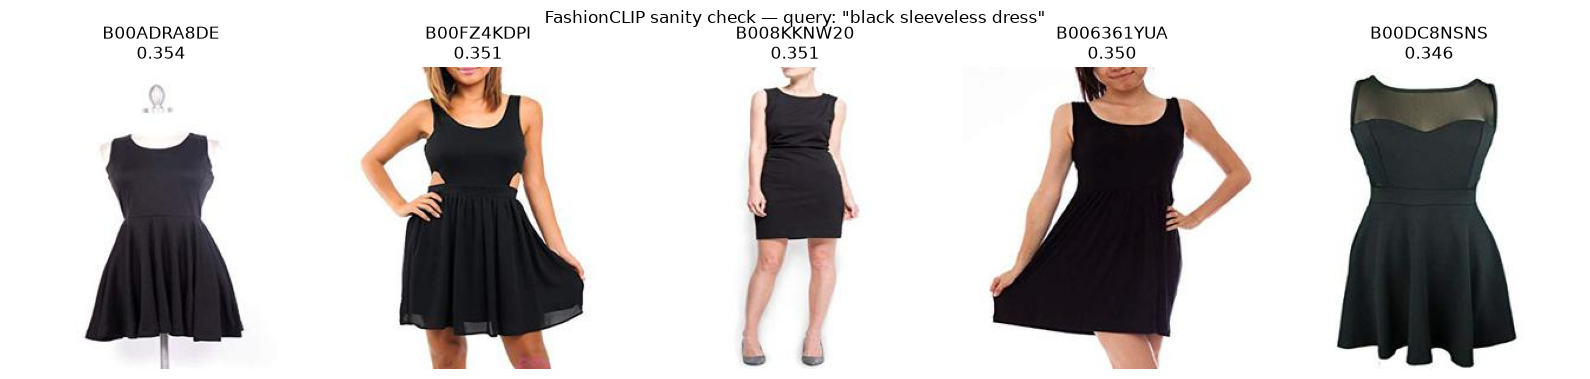

In [25]:
import matplotlib.pyplot as plt

QUERY_TEXT = "black sleeveless dress"

inputs = fclip_processor(
    text=[QUERY_TEXT],
    return_tensors="pt",
    padding=True,
    truncation=True,
)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.inference_mode():
    text_output = fclip_model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs.get("attention_mask"),
    )
    q = fclip_model.text_projection(text_output.pooler_output)
    q = F.normalize(q, p=2, dim=-1)
    q = q.cpu().numpy().astype("float32")[0]

scores = fashionclip_image_embeddings @ q
topk = np.argsort(-scores)[:5]

print("Query:", QUERY_TEXT)
for rank, idx in enumerate(topk, 1):
    row = fashionclip_image_map.iloc[idx]
    print(f"{rank}. {row['image_id']} | score={scores[idx]:.4f}")

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, idx in zip(axes, topk):
    row = fashionclip_image_map.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{row['image_id']}\n{scores[idx]:.3f}")
    ax.axis("off")

plt.suptitle(f'FashionCLIP sanity check — query: "{QUERY_TEXT}"')
plt.tight_layout()
plt.show()


# ***E — LƯU CẤU HÌNH THỰC NGHIỆM***


In [26]:
import datetime
import json
import os

run_config = {
    "date_local": datetime.datetime.now().isoformat(),
    "data_root": str(DATA_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "sbert_model": SBERT_MODEL_NAME,
    "fashionclip_model": FCLIP_MODEL_NAME,
    "sbert_batch": SBERT_BATCH,
    "fashionclip_text_batch": FCLIP_TEXT_BATCH,
    "fashionclip_image_batch": FCLIP_IMAGE_BATCH,
    "image_chunk_size": IMAGE_CHUNK_SIZE,
    "caption_strategy": "concat captions with '. '",
    "normalization": "L2 normalize all embeddings",
    "device": device,
    "cpu_threads": torch.get_num_threads() if device == "cpu" else None,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "num_triplets": int(len(triplets)),
    "num_images": int(len(image_df)),
    "sbert_shape": list(sbert_embeddings.shape),
    "fashionclip_text_shape": list(fclip_text_embeddings.shape),
    "fashionclip_image_shape": list(fashionclip_image_embeddings.shape),
}

config_file = OUTPUT_ROOT / "run_config.json"

with open(config_file, "w", encoding="utf-8") as f:
    json.dump(run_config, f, ensure_ascii=False, indent=2)

print(json.dumps(run_config, ensure_ascii=False, indent=2))
print("\nSaved:", config_file)


{
  "date_local": "2026-09-15T21:34:49.763314",
  "data_root": "C:\\Users\\Nguyen Ho Vinh  Hien\\Downloads\\FashionIQ\\fashionIQ_dataset",
  "output_root": "C:\\Users\\Nguyen Ho Vinh  Hien\\Downloads\\KHOALUAN\\Week37\\embeddings",
  "sbert_model": "sentence-transformers/all-mpnet-base-v2",
  "fashionclip_model": "patrickjohncyh/fashion-clip",
  "sbert_batch": 64,
  "fashionclip_text_batch": 64,
  "fashionclip_image_batch": 8,
  "image_chunk_size": 500,
  "caption_strategy": "concat captions with '. '",
  "normalization": "L2 normalize all embeddings",
  "device": "cpu",
  "cpu_threads": 11,
  "gpu": null,
  "num_triplets": 90402,
  "num_images": 74381,
  "sbert_shape": [
    90402,
    768
  ],
  "fashionclip_text_shape": [
    90402,
    512
  ],
  "fashionclip_image_shape": [
    74381,
    512
  ]
}

Saved: C:\Users\Nguyen Ho Vinh  Hien\Downloads\KHOALUAN\Week37\embeddings\run_config.json
